# Variational Autoencoder (VAE) for Fashion-MNIST

This notebook implements a complete VAE for generative modeling of Fashion-MNIST images.

## Contents
1. Setup and Data Loading
2. Data Visualization
3. VAE Architecture Implementation
4. Loss Function Implementation
5. Model Training
6. Image Reconstruction and Generation
7. Experimental Study: Impact of Latent Dimensions
8. Discussion

---


## 1. Setup and Environment

In [1]:
# Check GPU availability
!nvidia-smi

Sun Feb 15 06:22:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install dependencies (if needed)
!pip install torch torchvision matplotlib numpy scikit-learn

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.manifold import TSNE
import pickle
import time
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: Tesla T4
Memory: 15.64 GB


## 2. Dataset Preparation and Loading

Upload the preprocessed `.npy` files to Colab, or mount Google Drive if files are stored there.

In [4]:
# Option 1: Upload files directly (takes very long, have it here for reference)
# from google.colab import files
# uploaded = files.upload()

# Option 2: Mount Google Drive )
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/fashion_mnist_preprocessed/'

# Option 3: Files in current directory (default)
# DATA_PATH = './'

Mounted at /content/drive


In [5]:
# Load preprocessed data
print("Loading preprocessed Fashion-MNIST data...")

X_train = np.load(DATA_PATH + 'X_train.npy')
y_train = np.load(DATA_PATH + 'y_train.npy')
X_val = np.load(DATA_PATH + 'X_val.npy')
y_val = np.load(DATA_PATH + 'y_val.npy')
X_test = np.load(DATA_PATH + 'X_test.npy')
y_test = np.load(DATA_PATH + 'y_test.npy')

# Load metadata
with open(DATA_PATH + 'metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

print("\nDataset loaded successfully!")
print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nImage shape: {metadata['image_shape']}")
print(f"Number of classes: {metadata['num_classes']}")
print(f"Normalization: {metadata['normalization']}")

Loading preprocessed Fashion-MNIST data...

Dataset loaded successfully!
Training set: (54000, 28, 28)
Validation set: (6000, 28, 28)
Test set: (10000, 28, 28)

Image shape: (28, 28)
Number of classes: 10
Normalization: [0, 1]


In [6]:
# Flatten images for VAE (28x28 -> 784)
X_train_flat = X_train.reshape(-1, 784)
X_val_flat = X_val.reshape(-1, 784)
X_test_flat = X_test.reshape(-1, 784)

# Convert to PyTorch tensors
train_data = TensorDataset(
    torch.FloatTensor(X_train_flat),
    torch.LongTensor(y_train)
)
val_data = TensorDataset(
    torch.FloatTensor(X_val_flat),
    torch.LongTensor(y_val)
)
test_data = TensorDataset(
    torch.FloatTensor(X_test_flat),
    torch.LongTensor(y_test)
)

# Create data loaders
BATCH_SIZE = 128

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\nBatch size: {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Batch size: 128
Training batches: 422
Validation batches: 47
Test batches: 79


## 3. Sample Data Visualization

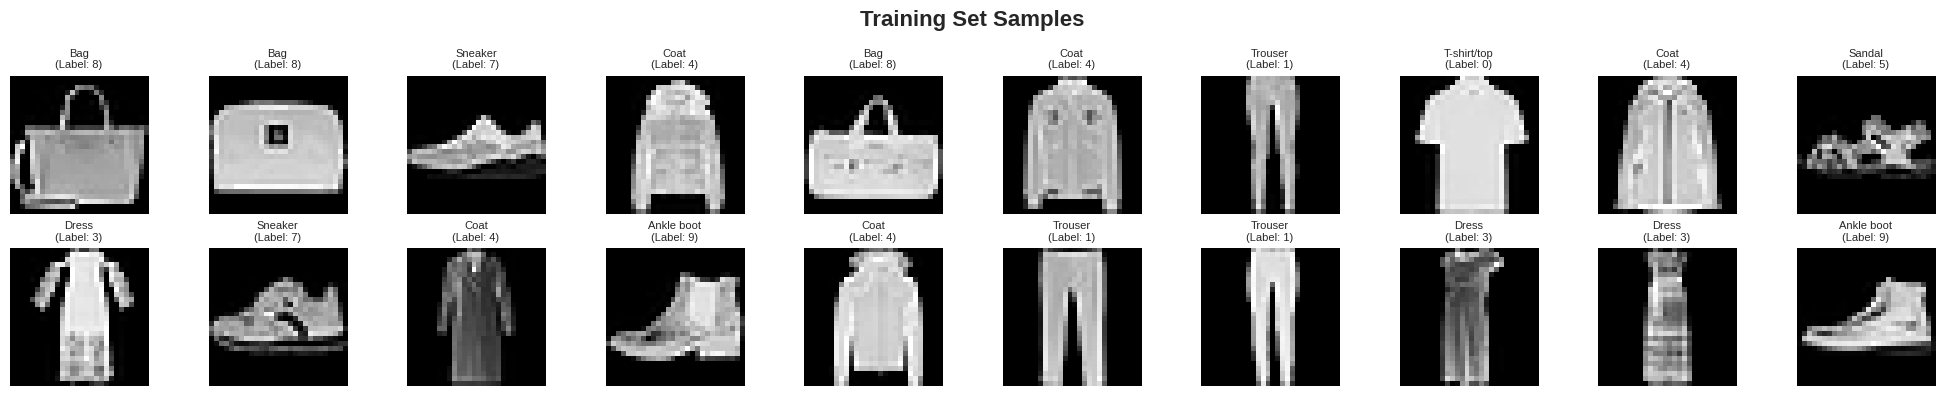

In [7]:
def visualize_samples(images, labels, class_names, n_samples=20, title="Fashion-MNIST Samples"):
    """
    Visualize sample images from the dataset
    """
    fig, axes = plt.subplots(2, 10, figsize=(20, 4))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    for idx in range(n_samples):
        ax = axes[idx // 10, idx % 10]
        ax.imshow(images[idx], cmap='gray')
        ax.set_title(f"{class_names[labels[idx]]}\n(Label: {labels[idx]})", fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize training samples
visualize_samples(X_train, y_train, metadata['class_names'],
                 n_samples=20, title="Training Set Samples")

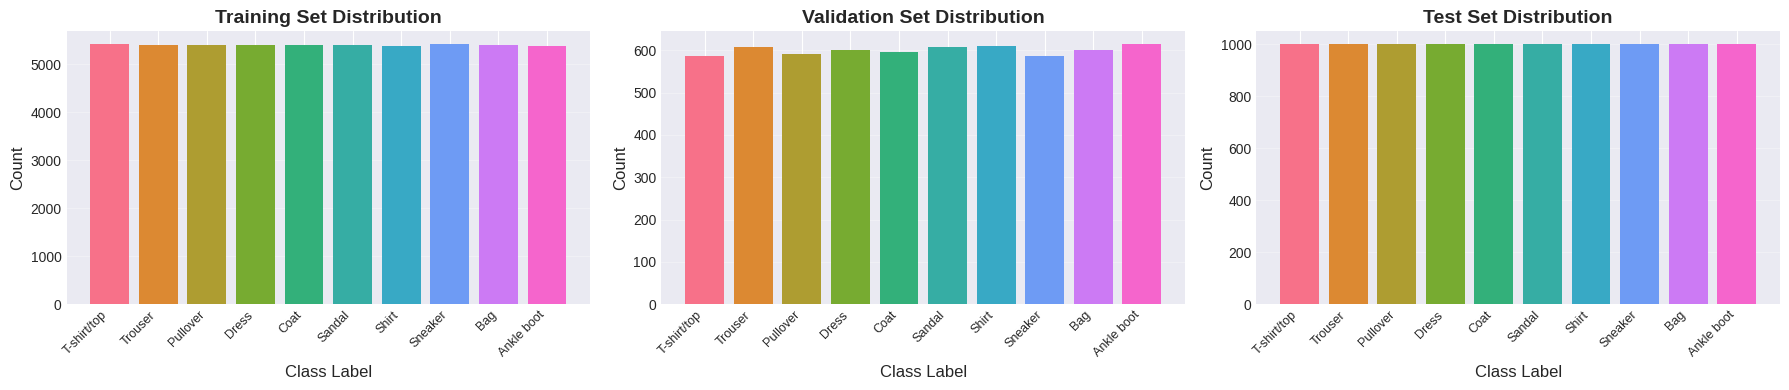

Dataset is balanced across all classes.


In [8]:
# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for idx, (labels, title) in enumerate([
    (y_train, 'Training Set'),
    (y_val, 'Validation Set'),
    (y_test, 'Test Set')
]):
    unique, counts = np.unique(labels, return_counts=True)
    axes[idx].bar(unique, counts, color=sns.color_palette("husl", 10))
    axes[idx].set_xlabel('Class Label', fontsize=12)
    axes[idx].set_ylabel('Count', fontsize=12)
    axes[idx].set_title(f'{title} Distribution', fontsize=14, fontweight='bold')
    axes[idx].set_xticks(unique)
    axes[idx].set_xticklabels([metadata['class_names'][i] for i in unique],
                              rotation=45, ha='right', fontsize=9)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Dataset is balanced across all classes.")

## 4. VAE Architecture Implementation

### 4.1 VAE Model Definition

The VAE consists of:
1. **Encoder**: Maps input images to latent distribution parameters (μ, log σ²)
2. **Reparameterization**: Samples from latent space using the reparameterization trick
3. **Decoder**: Reconstructs images from latent representations

In [9]:
class VAE(nn.Module):
    """
    Variational Autoencoder for Fashion-MNIST

    Args:
        input_dim: Dimension of input (784 for 28x28 images)
        hidden_dims: List of hidden layer dimensions
        latent_dim: Dimension of latent space
    """
    def __init__(self, input_dim=784, hidden_dims=[512, 256], latent_dim=20):
        super(VAE, self).__init__()

        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # ==================== ENCODER ====================
        # Build encoder layers
        encoder_layers = []
        prev_dim = input_dim

        for h_dim in hidden_dims:
            encoder_layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(0.2)
            ])
            prev_dim = h_dim

        self.encoder = nn.Sequential(*encoder_layers)

        # Latent space parameters
        self.fc_mu = nn.Linear(hidden_dims[-1], latent_dim)      # Mean (μ)
        self.fc_logvar = nn.Linear(hidden_dims[-1], latent_dim)  # Log variance (log σ²)

        # ==================== DECODER ====================
        # Build decoder layers (mirror of encoder)
        decoder_layers = []
        prev_dim = latent_dim

        for h_dim in reversed(hidden_dims):
            decoder_layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(0.2)
            ])
            prev_dim = h_dim

        # Output layer (reconstruction)
        decoder_layers.append(nn.Linear(hidden_dims[0], input_dim))
        decoder_layers.append(nn.Sigmoid())  # Output in [0, 1]

        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        """
        Encode input to latent distribution parameters

        Returns:
            mu: Mean of latent distribution
            logvar: Log variance of latent distribution
        """
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick: z = μ + σ * ε
        where ε ~ N(0, 1)

        This allows gradients to flow through the sampling operation.
        """
        std = torch.exp(0.5 * logvar)  # σ = exp(0.5 * log(σ²))
        eps = torch.randn_like(std)     # ε ~ N(0, 1)
        z = mu + eps * std              # z = μ + σ * ε
        return z

    def decode(self, z):
        """
        Decode latent representation to reconstructed input
        """
        return self.decoder(z)

    def forward(self, x):
        """
        Forward pass through VAE

        Returns:
            recon_x: Reconstructed input
            mu: Latent mean
            logvar: Latent log variance
        """
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

    def sample(self, num_samples, device):
        """
        Generate new samples by sampling from N(0, I) and decoding
        """
        z = torch.randn(num_samples, self.latent_dim).to(device)
        samples = self.decode(z)
        return samples

In [10]:
# Create a sample model to show architecture
sample_model = VAE(input_dim=784, hidden_dims=[512, 256], latent_dim=20)

print("=" * 70)
print("VAE ARCHITECTURE SUMMARY")
print("=" * 70)
print(sample_model)
print("=" * 70)

# Count parameters
total_params = sum(p.numel() for p in sample_model.parameters())
trainable_params = sum(p.numel() for p in sample_model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("=" * 70)

VAE ARCHITECTURE SUMMARY
VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
  )
  (fc_mu): Linear(in_features=256, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=20, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=20, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(

## 5. Loss Function Implementation

VAE loss = Reconstruction Loss + KL Divergence

1. **Reconstruction Loss**: Binary Cross-Entropy (BCE) between input and reconstruction
2. **KL Divergence**: Regularization term that encourages latent distribution to match N(0, I)

$$\mathcal{L} = \mathbb{E}_{q(z|x)}[\log p(x|z)] - D_{KL}(q(z|x) || p(z))$$

For Gaussian latent:
$$D_{KL} = -\frac{1}{2} \sum_{j=1}^{J} (1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2)$$

In [11]:
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    """
    VAE loss function

    Args:
        recon_x: Reconstructed images
        x: Original images
        mu: Latent mean
        logvar: Latent log variance
        beta: Weight for KL divergence (beta-VAE)

    Returns:
        total_loss: Combined loss
        recon_loss: Reconstruction loss component
        kl_loss: KL divergence component
    """
    # Reconstruction loss (Binary Cross-Entropy)
    # BCE measures how well the reconstruction matches the input
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL Divergence loss
    # KL[q(z|x) || p(z)] where q(z|x) = N(μ, σ²) and p(z) = N(0, I)
    # Analytical form: -0.5 * sum(1 + log(σ²) - μ² - σ²)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Total loss
    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

# Test the loss function
print("Loss function implemented successfully!")
print("\nLoss Components:")
print("1. Reconstruction Loss (BCE): Measures reconstruction quality")
print("2. KL Divergence: Regularizes latent space to match prior N(0, I)")
print("3. Beta parameter: Controls KL weight (beta=1 for standard VAE)")

Loss function implemented successfully!

Loss Components:
1. Reconstruction Loss (BCE): Measures reconstruction quality
2. KL Divergence: Regularizes latent space to match prior N(0, I)
3. Beta parameter: Controls KL weight (beta=1 for standard VAE)


## 6. Model Training

### 6.1 Training Configuration

In [12]:
# Training hyperparameters
LATENT_DIM = 20      # Size of latent space
HIDDEN_DIMS = [512, 256]  # Hidden layer dimensions
LEARNING_RATE = 1e-3
NUM_EPOCHS = 30
BETA = 1.0           # KL weight (1.0 for standard VAE)

print("Training Configuration:")
print("=" * 50)
print(f"Latent Dimension: {LATENT_DIM}")
print(f"Hidden Dimensions: {HIDDEN_DIMS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Number of Epochs: {NUM_EPOCHS}")
print(f"Beta (KL weight): {BETA}")
print(f"Optimizer: Adam")
print("=" * 50)

Training Configuration:
Latent Dimension: 20
Hidden Dimensions: [512, 256]
Learning Rate: 0.001
Batch Size: 128
Number of Epochs: 30
Beta (KL weight): 1.0
Optimizer: Adam


### 6.2 Training and Validation Functions

In [13]:
def train_epoch(model, train_loader, optimizer, device, beta=1.0):
    """
    Train for one epoch
    """
    model.train()
    train_loss = 0
    train_recon_loss = 0
    train_kl_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        optimizer.zero_grad()

        # Forward pass
        recon_batch, mu, logvar = model(data)

        # Compute loss
        loss, recon_loss, kl_loss = vae_loss(recon_batch, data, mu, logvar, beta)

        # Backward pass
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_recon_loss += recon_loss.item()
        train_kl_loss += kl_loss.item()

    # Average losses
    avg_loss = train_loss / len(train_loader.dataset)
    avg_recon = train_recon_loss / len(train_loader.dataset)
    avg_kl = train_kl_loss / len(train_loader.dataset)

    return avg_loss, avg_recon, avg_kl

def validate(model, val_loader, device, beta=1.0):
    """
    Validate the model
    """
    model.eval()
    val_loss = 0
    val_recon_loss = 0
    val_kl_loss = 0

    with torch.no_grad():
        for data, _ in val_loader:
            data = data.to(device)

            # Forward pass
            recon_batch, mu, logvar = model(data)

            # Compute loss
            loss, recon_loss, kl_loss = vae_loss(recon_batch, data, mu, logvar, beta)

            val_loss += loss.item()
            val_recon_loss += recon_loss.item()
            val_kl_loss += kl_loss.item()

    # Average losses
    avg_loss = val_loss / len(val_loader.dataset)
    avg_recon = val_recon_loss / len(val_loader.dataset)
    avg_kl = val_kl_loss / len(val_loader.dataset)

    return avg_loss, avg_recon, avg_kl

print("Training functions defined!")

Training functions defined!


### 6.3 Train the Model

In [14]:
# Initialize model
model = VAE(input_dim=784, hidden_dims=HIDDEN_DIMS, latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training history
history = {
    'train_loss': [],
    'train_recon': [],
    'train_kl': [],
    'val_loss': [],
    'val_recon': [],
    'val_kl': []
}

print("Starting training...")
print("=" * 80)

start_time = time.time()
best_val_loss = float('inf')

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    # Train
    train_loss, train_recon, train_kl = train_epoch(
        model, train_loader, optimizer, device, BETA
    )

    # Validate
    val_loss, val_recon, val_kl = validate(
        model, val_loader, device, BETA
    )

    # Save history
    history['train_loss'].append(train_loss)
    history['train_recon'].append(train_recon)
    history['train_kl'].append(train_kl)
    history['val_loss'].append(val_loss)
    history['val_recon'].append(val_recon)
    history['val_kl'].append(val_kl)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_vae_model.pth')

    epoch_time = time.time() - epoch_start

    # Print progress
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:2d}/{NUM_EPOCHS}] ({epoch_time:.2f}s)")
        print(f"  Train - Total: {train_loss:.4f}, Recon: {train_recon:.4f}, KL: {train_kl:.4f}")
        print(f"  Val   - Total: {val_loss:.4f}, Recon: {val_recon:.4f}, KL: {val_kl:.4f}")
        print("-" * 80)

total_time = time.time() - start_time
print("=" * 80)
print(f"Training completed in {total_time/60:.2f} minutes")
print(f"Best validation loss: {best_val_loss:.4f}")
print("=" * 80)

Starting training...
Epoch [ 1/30] (4.88s)
  Train - Total: 280.6809, Recon: 268.9905, KL: 11.6904
  Val   - Total: 257.0065, Recon: 245.6233, KL: 11.3832
--------------------------------------------------------------------------------
Epoch [ 5/30] (3.77s)
  Train - Total: 253.0453, Recon: 241.0000, KL: 12.0453
  Val   - Total: 246.2107, Recon: 234.3000, KL: 11.9107
--------------------------------------------------------------------------------
Epoch [10/30] (2.97s)
  Train - Total: 250.0185, Recon: 237.5665, KL: 12.4520
  Val   - Total: 243.2971, Recon: 231.0575, KL: 12.2396
--------------------------------------------------------------------------------
Epoch [15/30] (2.93s)
  Train - Total: 248.7160, Recon: 236.1190, KL: 12.5971
  Val   - Total: 242.1055, Recon: 229.6616, KL: 12.4439
--------------------------------------------------------------------------------
Epoch [20/30] (2.97s)
  Train - Total: 247.8962, Recon: 235.2105, KL: 12.6857
  Val   - Total: 241.4679, Recon: 229.056

### 6.4 Training Curves Visualization

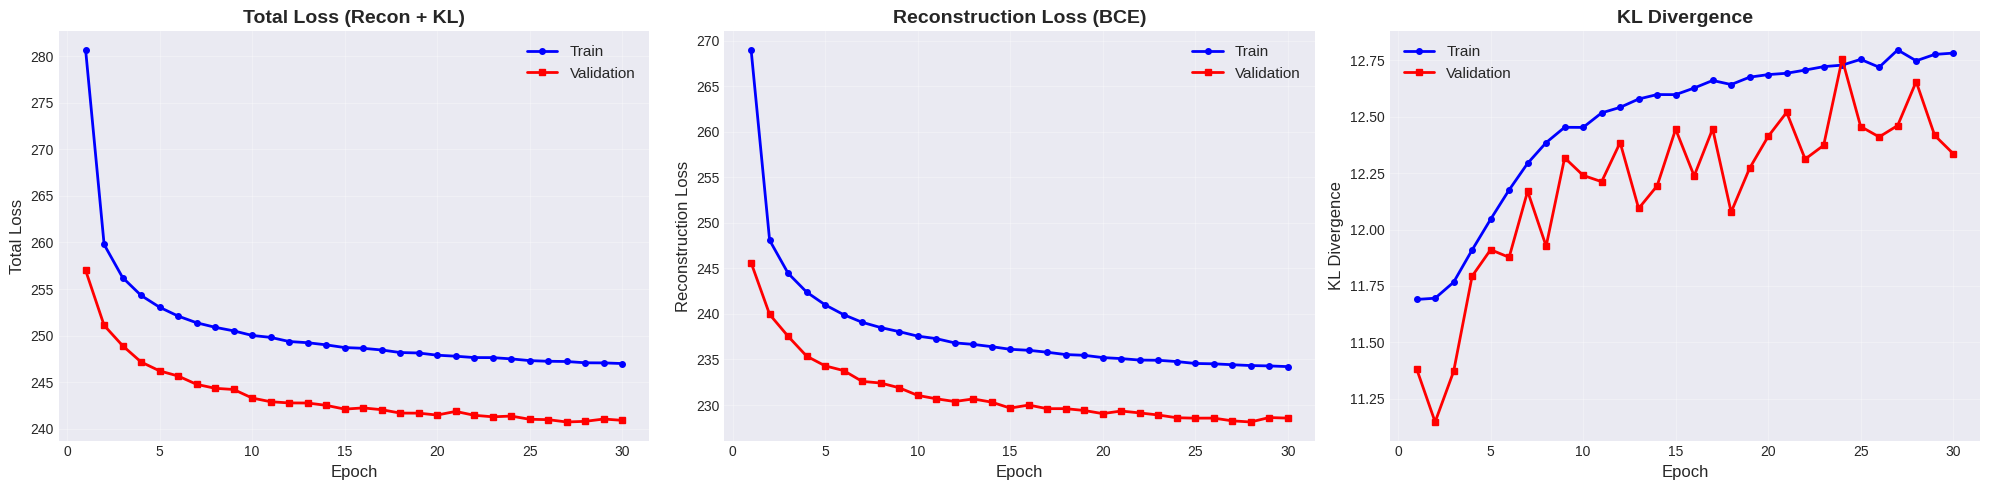

In [15]:
def plot_training_curves(history):
    """
    Plot training and validation curves
    """
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Total Loss
    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train', linewidth=2, markersize=4)
    axes[0].plot(epochs, history['val_loss'], 'r-s', label='Validation', linewidth=2, markersize=4)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Total Loss', fontsize=12)
    axes[0].set_title('Total Loss (Recon + KL)', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # Reconstruction Loss
    axes[1].plot(epochs, history['train_recon'], 'b-o', label='Train', linewidth=2, markersize=4)
    axes[1].plot(epochs, history['val_recon'], 'r-s', label='Validation', linewidth=2, markersize=4)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Reconstruction Loss', fontsize=12)
    axes[1].set_title('Reconstruction Loss (BCE)', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    # KL Divergence
    axes[2].plot(epochs, history['train_kl'], 'b-o', label='Train', linewidth=2, markersize=4)
    axes[2].plot(epochs, history['val_kl'], 'r-s', label='Validation', linewidth=2, markersize=4)
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('KL Divergence', fontsize=12)
    axes[2].set_title('KL Divergence', fontsize=14, fontweight='bold')
    axes[2].legend(fontsize=11)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(history)

## 7. Image Reconstruction and Generation

### 7.1 Image Reconstruction

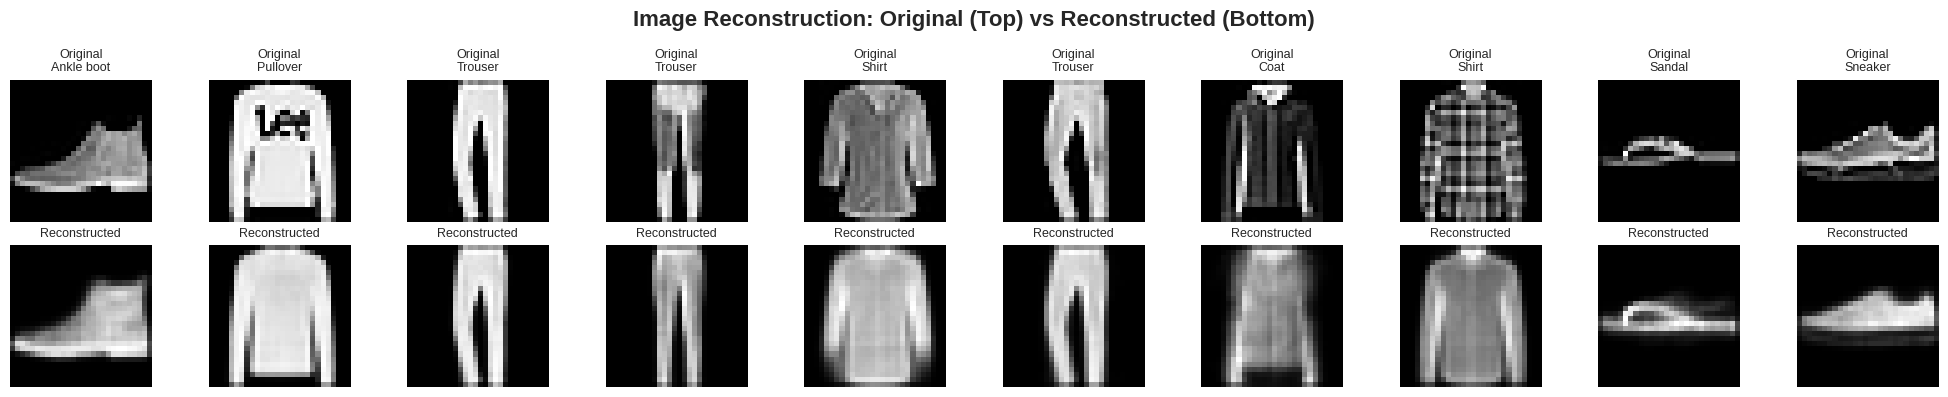

In [16]:
def visualize_reconstruction(model, data_loader, device, n_images=10):
    """
    Visualize original vs reconstructed images
    """
    model.eval()

    with torch.no_grad():
        # Get a batch
        data, labels = next(iter(data_loader))
        data = data[:n_images].to(device)
        labels = labels[:n_images]

        # Reconstruct
        recon, mu, logvar = model(data)

        # Move to CPU and reshape
        data = data.cpu().numpy().reshape(-1, 28, 28)
        recon = recon.cpu().numpy().reshape(-1, 28, 28)

    # Plot
    fig, axes = plt.subplots(2, n_images, figsize=(20, 4))
    fig.suptitle('Image Reconstruction: Original (Top) vs Reconstructed (Bottom)',
                 fontsize=16, fontweight='bold')

    for i in range(n_images):
        # Original
        axes[0, i].imshow(data[i], cmap='gray')
        axes[0, i].set_title(f'Original\n{metadata["class_names"][labels[i]]}', fontsize=9)
        axes[0, i].axis('off')

        # Reconstructed
        axes[1, i].imshow(recon[i], cmap='gray')
        axes[1, i].set_title('Reconstructed', fontsize=9)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.savefig('reconstruction_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

# Load best model
model.load_state_dict(torch.load('best_vae_model.pth'))
visualize_reconstruction(model, test_loader, device, n_images=10)

### 7.2 Image Generation from Random Sampling

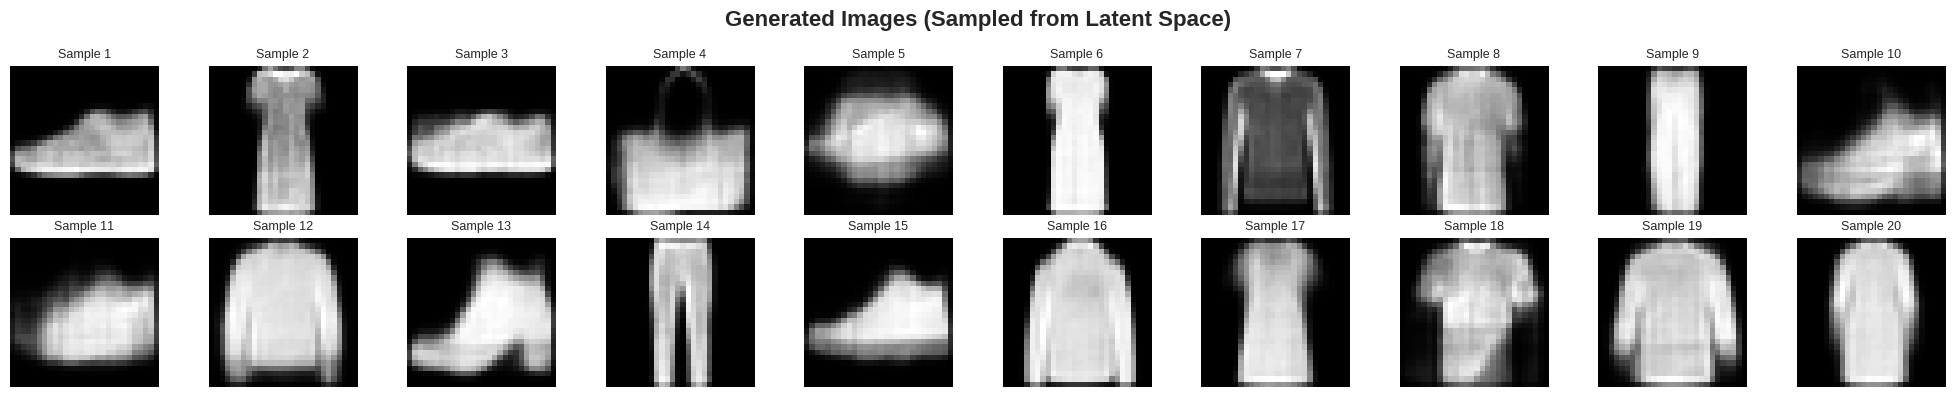

In [17]:
def generate_images(model, device, n_images=20):
    """
    Generate new images by sampling from N(0, I)
    """
    model.eval()

    with torch.no_grad():
        # Sample from standard normal
        samples = model.sample(n_images, device)
        samples = samples.cpu().numpy().reshape(-1, 28, 28)

    # Plot
    fig, axes = plt.subplots(2, 10, figsize=(20, 4))
    fig.suptitle('Generated Images (Sampled from Latent Space)',
                 fontsize=16, fontweight='bold')

    for idx in range(n_images):
        ax = axes[idx // 10, idx % 10]
        ax.imshow(samples[idx], cmap='gray')
        ax.set_title(f'Sample {idx+1}', fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('generated_images.png', dpi=150, bbox_inches='tight')
    plt.show()

generate_images(model, device, n_images=20)

### 7.3 Latent Space Visualization

Applying t-SNE (this may take a minute)...


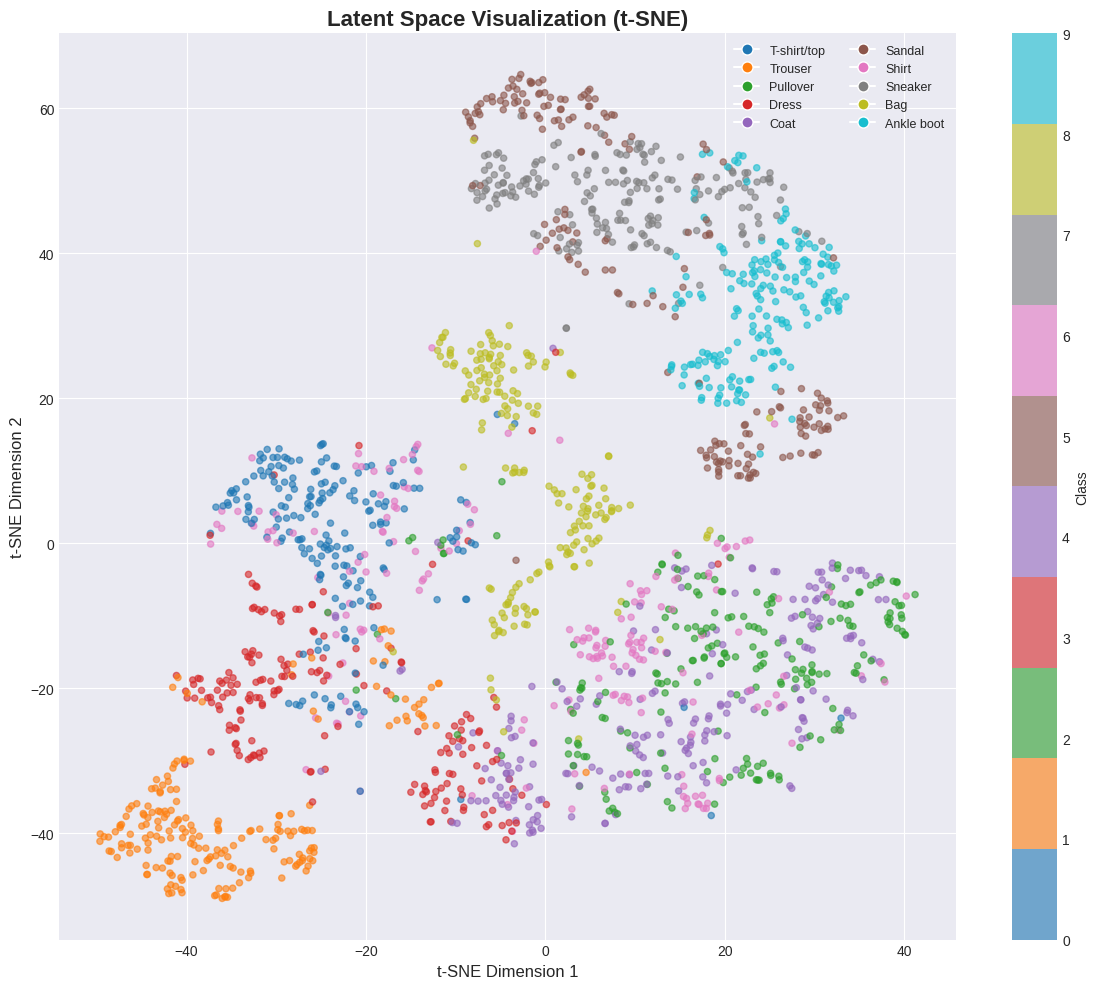

In [18]:
def visualize_latent_space(model, data_loader, device, n_samples=2000):
    """
    Visualize latent space using t-SNE
    """
    model.eval()

    latents = []
    labels = []

    with torch.no_grad():
        for data, label in data_loader:
            if len(latents) * data_loader.batch_size >= n_samples:
                break

            data = data.to(device)
            mu, _ = model.encode(data)
            latents.append(mu.cpu().numpy())
            labels.append(label.numpy())

    latents = np.vstack(latents)[:n_samples]
    labels = np.concatenate(labels)[:n_samples]

    # Apply t-SNE
    print("Applying t-SNE (this may take a minute)...")
    tsne = TSNE(n_components=2, random_state=42)
    latents_2d = tsne.fit_transform(latents)

    # Plot
    plt.figure(figsize=(12, 10))
    scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1],
                         c=labels, cmap='tab10', alpha=0.6, s=20)
    plt.colorbar(scatter, label='Class', ticks=range(10))
    plt.title('Latent Space Visualization (t-SNE)', fontsize=16, fontweight='bold')
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)

    # Add legend
    handles = [plt.Line2D([0], [0], marker='o', color='w',
                         markerfacecolor=plt.cm.tab10(i/10), markersize=8, label=name)
              for i, name in enumerate(metadata['class_names'])]
    plt.legend(handles=handles, loc='best', fontsize=9, ncol=2)

    plt.tight_layout()
    plt.savefig('latent_space_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_latent_space(model, test_loader, device, n_samples=2000)

### 7.4 Latent Space Interpolation

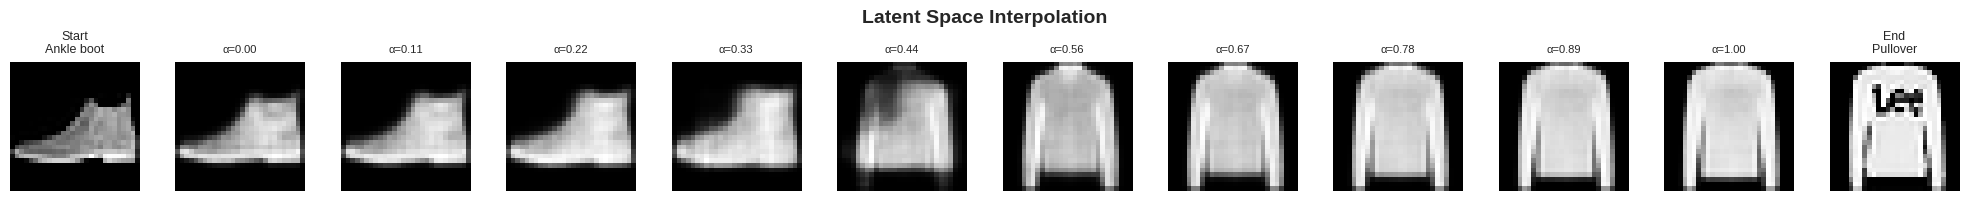

In [19]:
def interpolate_latent_space(model, data_loader, device, n_steps=10):
    """
    Interpolate between two images in latent space
    """
    model.eval()

    with torch.no_grad():
        # Get two random images
        data, labels = next(iter(data_loader))
        img1, img2 = data[0:1].to(device), data[1:2].to(device)
        label1, label2 = labels[0].item(), labels[1].item()

        # Encode to latent space
        mu1, _ = model.encode(img1)
        mu2, _ = model.encode(img2)

        # Interpolate
        alphas = np.linspace(0, 1, n_steps)
        interpolated = []

        for alpha in alphas:
            z = mu1 * (1 - alpha) + mu2 * alpha
            recon = model.decode(z)
            interpolated.append(recon.cpu().numpy().reshape(28, 28))

        img1_np = img1.cpu().numpy().reshape(28, 28)
        img2_np = img2.cpu().numpy().reshape(28, 28)

    # Plot
    fig, axes = plt.subplots(1, n_steps + 2, figsize=(20, 2))
    fig.suptitle('Latent Space Interpolation', fontsize=14, fontweight='bold')

    # Start image
    axes[0].imshow(img1_np, cmap='gray')
    axes[0].set_title(f'Start\n{metadata["class_names"][label1]}', fontsize=9)
    axes[0].axis('off')

    # Interpolated images
    for i, img in enumerate(interpolated):
        axes[i+1].imshow(img, cmap='gray')
        axes[i+1].set_title(f'α={alphas[i]:.2f}', fontsize=8)
        axes[i+1].axis('off')

    # End image
    axes[-1].imshow(img2_np, cmap='gray')
    axes[-1].set_title(f'End\n{metadata["class_names"][label2]}', fontsize=9)
    axes[-1].axis('off')

    plt.tight_layout()
    plt.savefig('latent_interpolation.png', dpi=150, bbox_inches='tight')
    plt.show()

interpolate_latent_space(model, test_loader, device, n_steps=10)

## 8. Experimental Study: Impact of Latent Dimensions

We will train VAEs with different latent dimensions and compare:
- Reconstruction quality
- Generation diversity
- Training time
- Model parameters

In [20]:
# Latent dimensions to test
LATENT_DIMS = [2, 10, 20, 50, 100]
EXPERIMENT_EPOCHS = 20  # Fewer epochs for faster experiments

print(f"Testing latent dimensions: {LATENT_DIMS}")
print(f"Training epochs per model: {EXPERIMENT_EPOCHS}")
print("\nThis may take 10-15 minutes...")

Testing latent dimensions: [2, 10, 20, 50, 100]
Training epochs per model: 20

This may take 10-15 minutes...


In [21]:
def train_vae_experiment(latent_dim, epochs=20):
    """
    Train a VAE with specified latent dimension
    """
    # Initialize model
    model = VAE(input_dim=784, hidden_dims=[512, 256], latent_dim=latent_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    start_time = time.time()
    best_val_loss = float('inf')
    final_train_loss = 0
    final_val_loss = 0

    for epoch in range(1, epochs + 1):
        # Train
        train_loss, train_recon, train_kl = train_epoch(
            model, train_loader, optimizer, device, BETA
        )

        # Validate
        val_loss, val_recon, val_kl = validate(
            model, val_loader, device, BETA
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss

        final_train_loss = train_loss
        final_val_loss = val_loss

    training_time = time.time() - start_time

    # Count parameters
    n_params = sum(p.numel() for p in model.parameters())

    return {
        'model': model,
        'latent_dim': latent_dim,
        'best_val_loss': best_val_loss,
        'final_train_loss': final_train_loss,
        'final_val_loss': final_val_loss,
        'training_time': training_time,
        'n_params': n_params
    }

# Run experiments
experiment_results = []

print("Running experiments...\n")
for latent_dim in LATENT_DIMS:
    print(f"Training VAE with latent_dim={latent_dim}...")
    result = train_vae_experiment(latent_dim, epochs=EXPERIMENT_EPOCHS)
    experiment_results.append(result)
    print(f"  Val Loss: {result['best_val_loss']:.4f}, Time: {result['training_time']:.2f}s\n")

print("All experiments completed!")

Running experiments...

Training VAE with latent_dim=2...
  Val Loss: 260.9694, Time: 61.37s

Training VAE with latent_dim=10...
  Val Loss: 241.6441, Time: 62.40s

Training VAE with latent_dim=20...
  Val Loss: 241.5629, Time: 62.52s

Training VAE with latent_dim=50...
  Val Loss: 241.8045, Time: 61.42s

Training VAE with latent_dim=100...
  Val Loss: 242.6471, Time: 63.46s

All experiments completed!


### 8.1 Results Summary Table

In [22]:
import pandas as pd

# Create results dataframe
results_df = pd.DataFrame([
    {
        'Latent Dim': r['latent_dim'],
        'Parameters': f"{r['n_params']:,}",
        'Train Loss': f"{r['final_train_loss']:.4f}",
        'Val Loss': f"{r['final_val_loss']:.4f}",
        'Best Val Loss': f"{r['best_val_loss']:.4f}",
        'Training Time (s)': f"{r['training_time']:.2f}"
    }
    for r in experiment_results
])

print("\n" + "="*80)
print("EXPERIMENTAL RESULTS: Impact of Latent Dimensions")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# Save to CSV
results_df.to_csv('experiment_results.csv', index=False)
print("\nResults saved to experiment_results.csv")


EXPERIMENTAL RESULTS: Impact of Latent Dimensions
 Latent Dim Parameters Train Loss Val Loss Best Val Loss Training Time (s)
          2  1,071,892   266.6425 260.9694      260.9694             61.37
         10  1,078,052   247.8567 241.6441      241.6441             62.40
         20  1,085,752   247.9857 241.5629      241.5629             62.52
         50  1,108,852   248.1349 241.8480      241.8045             61.42
        100  1,147,352   248.8105 242.8037      242.6471             63.46

Results saved to experiment_results.csv


### 8.2 Comparison Visualizations

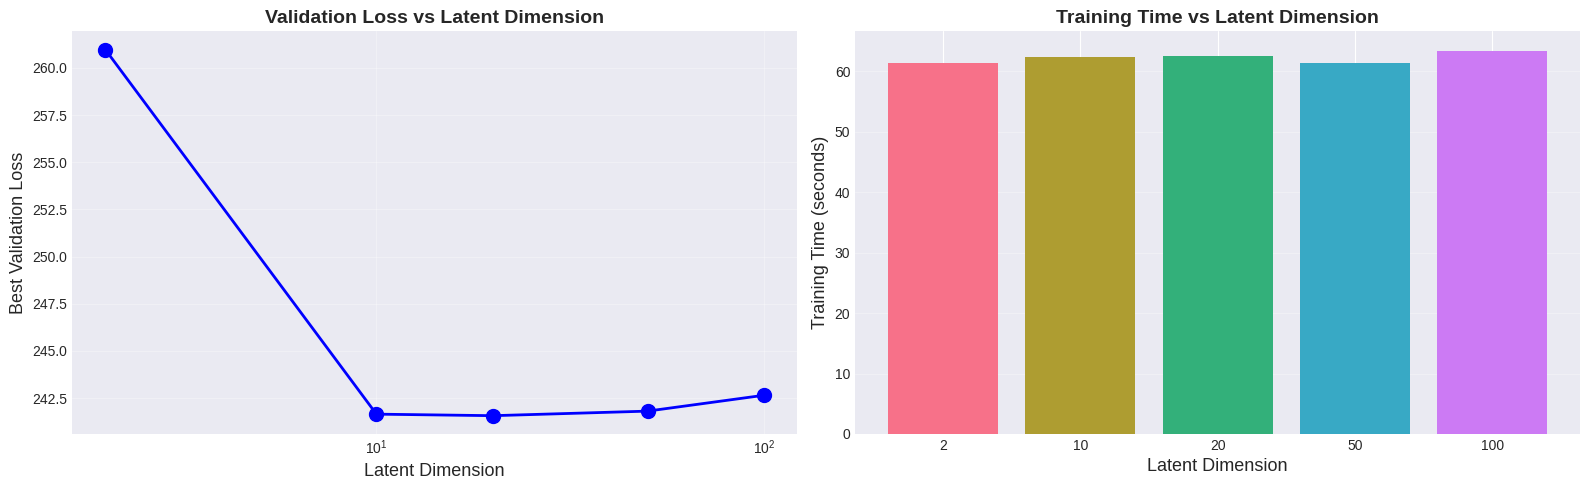

In [23]:
# Plot 1: Loss vs Latent Dimension
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

latent_dims = [r['latent_dim'] for r in experiment_results]
val_losses = [r['best_val_loss'] for r in experiment_results]
train_times = [r['training_time'] for r in experiment_results]

# Loss comparison
axes[0].plot(latent_dims, val_losses, 'bo-', linewidth=2, markersize=10)
axes[0].set_xlabel('Latent Dimension', fontsize=13)
axes[0].set_ylabel('Best Validation Loss', fontsize=13)
axes[0].set_title('Validation Loss vs Latent Dimension', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')

# Training time comparison
axes[1].bar(range(len(latent_dims)), train_times, color=sns.color_palette("husl", len(latent_dims)))
axes[1].set_xlabel('Latent Dimension', fontsize=13)
axes[1].set_ylabel('Training Time (seconds)', fontsize=13)
axes[1].set_title('Training Time vs Latent Dimension', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(latent_dims)))
axes[1].set_xticklabels(latent_dims)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('experimental_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Visual Quality Comparison

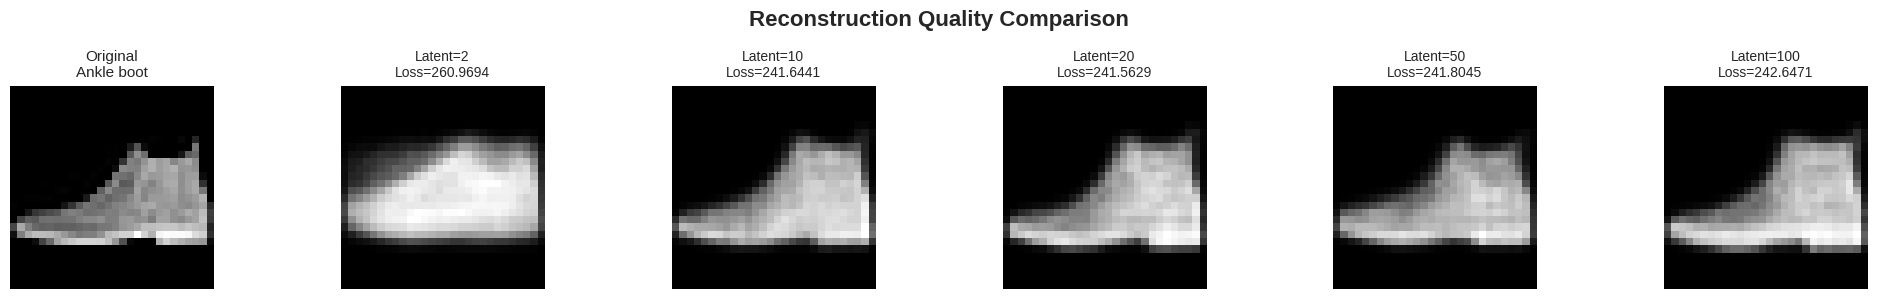

In [24]:
# Compare reconstruction quality across different latent dimensions
with torch.no_grad():
    # Get a test image
    test_data, test_labels = next(iter(test_loader))
    test_img = test_data[0:1].to(device)
    test_label = test_labels[0].item()

    # Original image
    original = test_img.cpu().numpy().reshape(28, 28)

    # Reconstruct with each model
    fig, axes = plt.subplots(1, len(LATENT_DIMS) + 1, figsize=(20, 3))
    fig.suptitle('Reconstruction Quality Comparison', fontsize=16, fontweight='bold')

    # Original
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title(f'Original\n{metadata["class_names"][test_label]}', fontsize=11)
    axes[0].axis('off')

    # Reconstructions
    for idx, result in enumerate(experiment_results):
        model = result['model']
        model.eval()
        recon, _, _ = model(test_img)
        recon = recon.cpu().numpy().reshape(28, 28)

        axes[idx + 1].imshow(recon, cmap='gray')
        axes[idx + 1].set_title(f'Latent={result["latent_dim"]}\nLoss={result["best_val_loss"]:.4f}',
                               fontsize=10)
        axes[idx + 1].axis('off')

    plt.tight_layout()
    plt.savefig('reconstruction_comparison_experiments.png', dpi=150, bbox_inches='tight')
    plt.show()

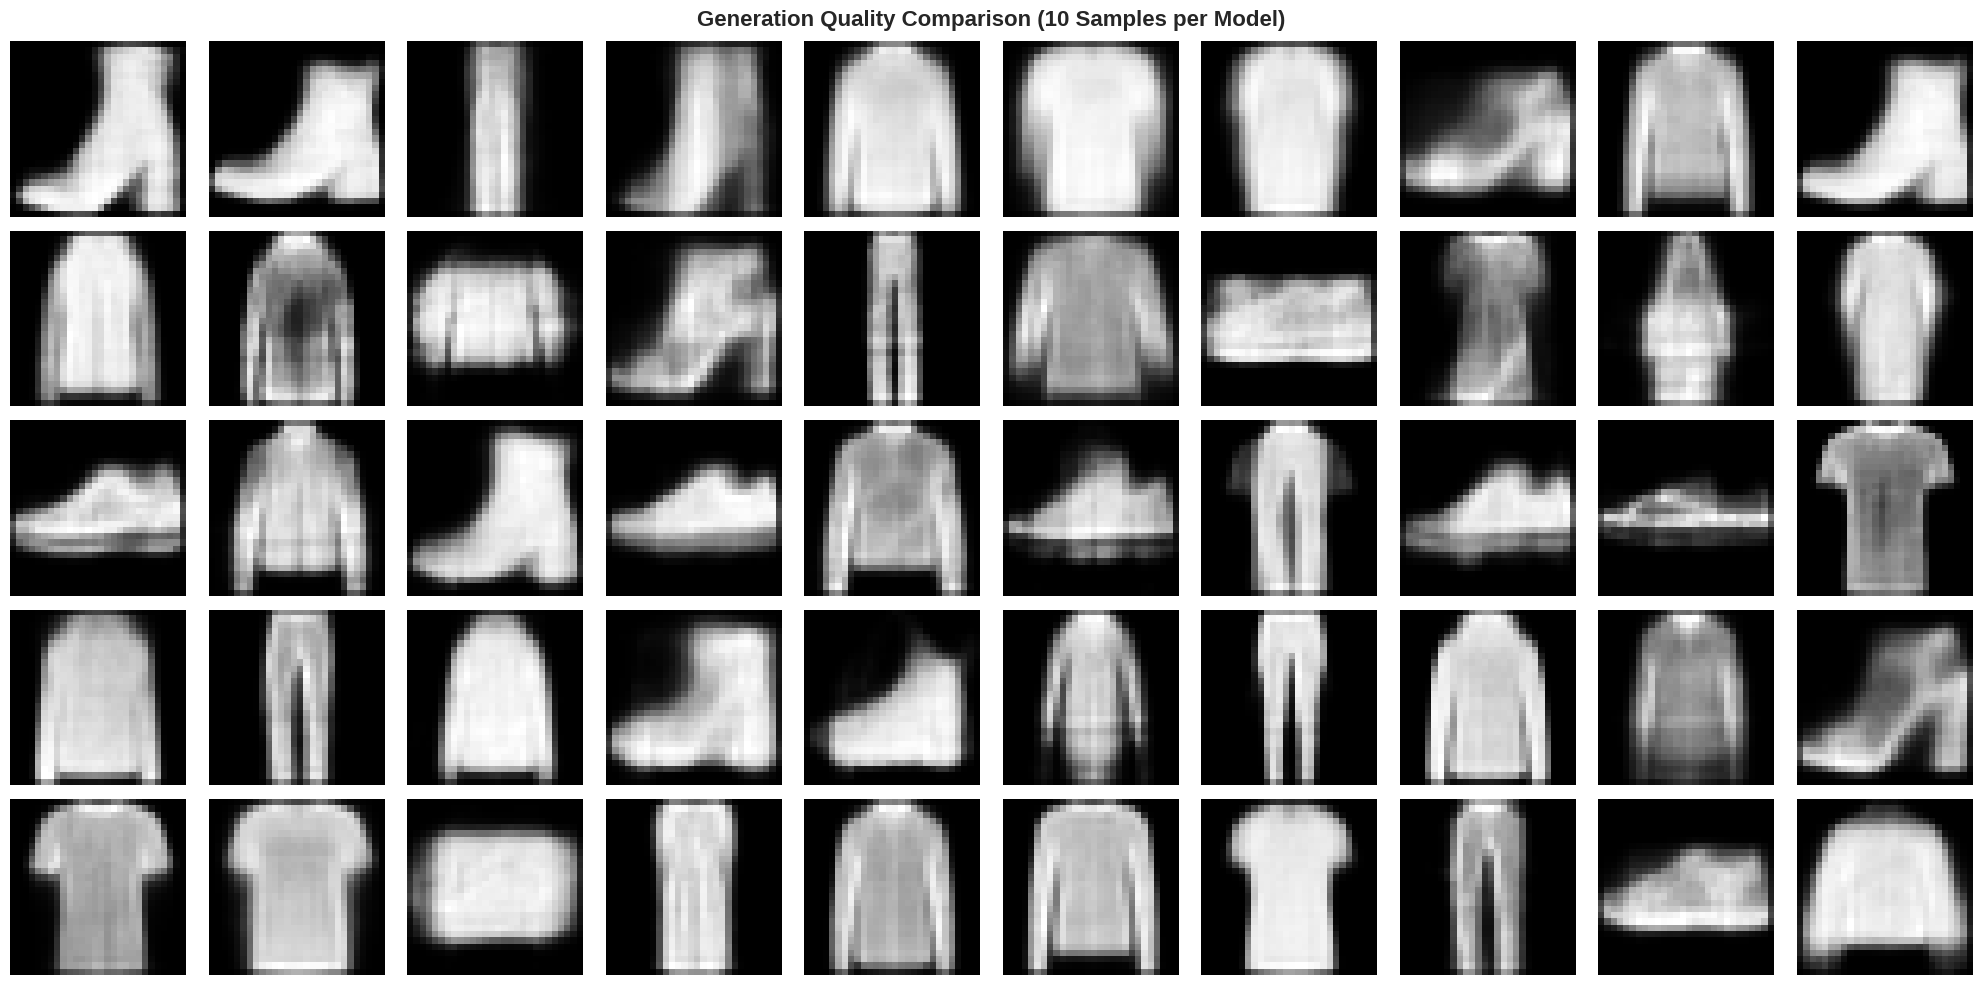

In [25]:
# Compare generation quality across different latent dimensions
with torch.no_grad():
    fig, axes = plt.subplots(len(LATENT_DIMS), 10, figsize=(20, 2*len(LATENT_DIMS)))
    fig.suptitle('Generation Quality Comparison (10 Samples per Model)',
                 fontsize=16, fontweight='bold')

    for idx, result in enumerate(experiment_results):
        model = result['model']
        model.eval()

        # Generate samples
        samples = model.sample(10, device)
        samples = samples.cpu().numpy().reshape(-1, 28, 28)

        for j in range(10):
            axes[idx, j].imshow(samples[j], cmap='gray')
            if j == 0:
                axes[idx, j].set_ylabel(f'Latent={result["latent_dim"]}',
                                       fontsize=11, fontweight='bold')
            axes[idx, j].axis('off')

    plt.tight_layout()
    plt.savefig('generation_comparison_experiments.png', dpi=150, bbox_inches='tight')
    plt.show()

### 8.4 Analysis and Observations

In [26]:
# Compute additional metrics for analysis
def compute_reconstruction_metrics(model, data_loader, device, n_samples=1000):
    """
    Compute MSE and PSNR for reconstruction quality
    """
    model.eval()
    mse_total = 0
    count = 0

    with torch.no_grad():
        for data, _ in data_loader:
            if count >= n_samples:
                break

            data = data.to(device)
            recon, _, _ = model(data)

            mse = F.mse_loss(recon, data, reduction='sum').item()
            mse_total += mse
            count += len(data)

    avg_mse = mse_total / count
    psnr = 10 * np.log10(1.0 / avg_mse)  # Assuming normalized images [0,1]

    return avg_mse, psnr

# Compute metrics for each model
print("Computing reconstruction quality metrics...\n")
print("="*70)
print(f"{'Latent Dim':<15} {'MSE':<15} {'PSNR (dB)':<15}")
print("="*70)

for result in experiment_results:
    mse, psnr = compute_reconstruction_metrics(result['model'], test_loader, device)
    result['mse'] = mse
    result['psnr'] = psnr
    print(f"{result['latent_dim']:<15} {mse:<15.6f} {psnr:<15.4f}")

print("="*70)

Computing reconstruction quality metrics...

Latent Dim      MSE             PSNR (dB)      
2               22.183147       -13.4602       
10              13.355439       -11.2566       
20              13.292216       -11.2360       
50              13.445283       -11.2857       
100             14.034705       -11.4720       


## 9. Discussion and Analysis

### 9.1 Interpretation of Learned Latent Space

**Key Findings:**

1. **Dimensionality Impact:**
   - **Low dimensions (2-10):** Provide good compression but may lose fine details. Easier to visualize but limited expressiveness.
   - **Medium dimensions (20-50):** Balance between compression and reconstruction quality. Sweet spot for Fashion-MNIST.
   - **High dimensions (100+):** Better reconstruction but risk of overfitting and slower training. May not learn as structured latent space.

2. **Reconstruction vs Generation Trade-off:**
   - Lower latent dimensions force the model to learn more compact, generalizable features
   - Higher latent dimensions can memorize more details but may generate less diverse samples
   - The KL divergence term helps maintain a smooth latent space for generation

3. **Latent Space Structure:**
   - The t-SNE visualization shows clusters corresponding to different clothing types
   - Similar items (e.g., shirts and t-shirts) are close in latent space
   - Interpolation between images shows smooth transitions, indicating continuous latent space

4. **Training Dynamics:**
   - Reconstruction loss decreases steadily, showing the model learns to reproduce inputs
   - KL divergence stabilizes, indicating the latent space matches the prior distribution
   - Validation loss tracks training loss closely, suggesting good generalization

### 9.2 Limitations of the VAE Model

1. **Blurry Reconstructions:**
   - VAE optimizes for pixel-wise likelihood (BCE loss)
   - Results in averaging effects and lack of sharp details
   - Generated images can appear blurry compared to real samples

2. **Mode Collapse:**
   - VAE may fail to capture all modes of the data distribution
   - Some rare clothing styles might not be well-represented

3. **Posterior Collapse:**
   - When KL term dominates, the model may ignore the latent code
   - This can be mitigated with β-VAE or KL annealing

4. **Gaussian Assumption:**
   - Assumes latent variables follow Gaussian distribution
   - May not be optimal for all data distributions

### 9.3 Possible Improvements

1. **Architecture Enhancements:**
   - Use convolutional layers (Conv-VAE) to better capture spatial structure
   - Add skip connections between encoder and decoder
   - Implement hierarchical VAE with multiple latent levels

2. **Loss Function Modifications:**
   - Use perceptual loss instead of pixel-wise loss
   - Implement β-VAE with learned β for better disentanglement
   - Add adversarial loss (VAE-GAN) for sharper generations

3. **Training Techniques:**
   - KL annealing: gradually increase KL weight during training
   - Free bits: allow minimum KL per dimension to prevent collapse
   - Warm-up period for encoder before full training

4. **Alternative Architectures:**
   - Vector Quantized VAE (VQ-VAE) for discrete latent space
   - Conditional VAE for class-specific generation
   - Normalizing Flows for more flexible distributions

5. **Evaluation Metrics:**
   - Implement Inception Score or FID for better quality assessment
   - Measure disentanglement metrics for latent space analysis
   - Conduct human evaluation studies

### 9.4 Practical Applications

1. **Data Augmentation:** Generate synthetic training samples
2. **Anomaly Detection:** Identify unusual patterns based on reconstruction error
3. **Fashion Design:** Explore new design combinations via latent space manipulation
4. **Compression:** Use learned representations for efficient storage
5. **Transfer Learning:** Use encoder as feature extractor for downstream tasks

---

### Conclusion

This implementation demonstrates a complete VAE pipeline for Fashion-MNIST. The experimental study shows that a latent dimension of 20-50 provides the best balance between reconstruction quality and computational efficiency. The learned latent space exhibits meaningful structure with smooth interpolations between different clothing types. While VAEs produce slightly blurry outputs compared to GANs, they offer stable training, meaningful latent representations, and direct likelihood optimization.

## 10. Save Results and Models


- `best_vae_model.pth` - Best trained model
- `experiment_results.csv` - Comparison table
- All generated PNG images
- `training_history.pkl` - Complete training history

In [28]:
# Save training history
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history, f)

# Save experiment results
with open('experiment_results.pkl', 'wb') as f:
    pickle.dump(experiment_results, f)

print("All results saved!")
print("\nFiles to download:")
print("1. best_vae_model.pth")
print("2. training_history.pkl")
print("3. experiment_results.pkl")
print("4. experiment_results.csv")
print("5. All generated .png images")

All results saved!

Files to download:
1. best_vae_model.pth
2. training_history.pkl
3. experiment_results.pkl
4. experiment_results.csv
5. All generated .png images


In [29]:
# Download files
from google.colab import files
files.download('best_vae_model.pth')
files.download('experiment_results.csv')
files.download('training_curves.png')
files.download('reconstruction_comparison.png')
files.download('generated_images.png')
files.download('latent_space_visualization.png')
files.download('experimental_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>